# Лабораторная работа №6

Егорова Варвара Александровна, 408575
****

Вариант 1

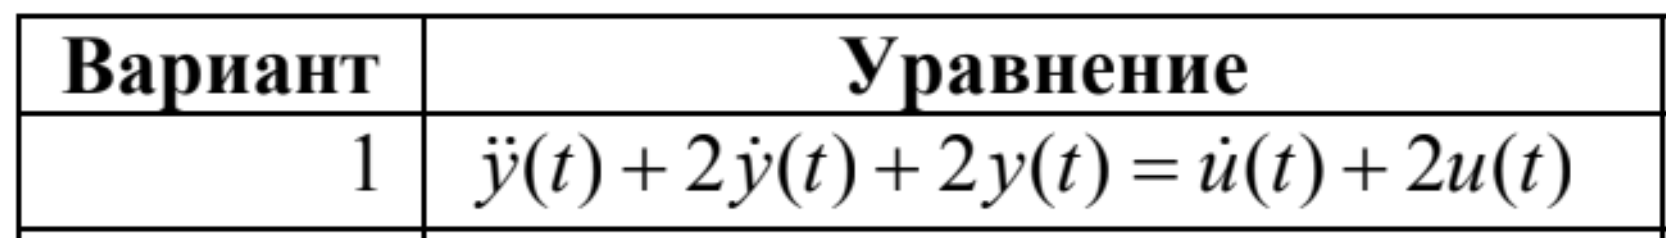

In [ ]:
!pip -q install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 23.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

In [ ]:
num = [1, 2]
den = [1, 2, 2]

W = ct.tf(num, den)

print("Передаточная функция W(s):")
print(W)

Передаточная функция W(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 2
  -------------
  s^2 + 2 s + 2


In [ ]:
poles = ct.poles(W)
zeros = ct.zeros(W)

print("Нули системы:")
print(zeros)

print("\nПолюса системы:")
print(poles)

is_stable = np.all(np.real(poles) < 0)

print("\nУстойчива ли непрерывная система?")
print(is_stable)

Нули системы:
[-2.+0.j]

Полюса системы:
[-1.+1.j -1.-1.j]

Устойчива ли непрерывная система?
True


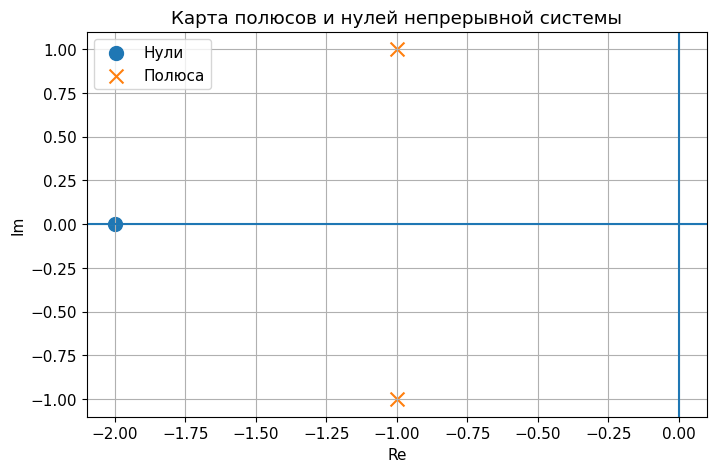

In [ ]:
plt.figure()

plt.scatter(np.real(zeros), np.imag(zeros), marker="o", s=100, label="Нули")
plt.scatter(np.real(poles), np.imag(poles), marker="x", s=100, label="Полюса")

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Карта полюсов и нулей непрерывной системы")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
A, B, C, D = ct.tf2ss(W).A, ct.tf2ss(W).B, ct.tf2ss(W).C, ct.tf2ss(W).D

print("Матрица A:")
print(A)

print("\nМатрица B:")
print(B)

print("\nМатрица C:")
print(C)

print("\nМатрица D:")
print(D)

Матрица A:
[[-2. -2.]
 [ 1.  0.]]

Матрица B:
[[1.]
 [0.]]

Матрица C:
[[1. 2.]]

Матрица D:
[[0.]]


In [ ]:
W_ss = ct.tf2ss(W)

A = np.array(W_ss.A)
B = np.array(W_ss.B)
C = np.array(W_ss.C)
D = np.array(W_ss.D)

ctrb_matrix = ct.ctrb(A, B)
obsv_matrix = ct.obsv(A, C)

rank_ctrb = np.linalg.matrix_rank(ctrb_matrix)
rank_obsv = np.linalg.matrix_rank(obsv_matrix)

n = A.shape[0]

print("Матрица управляемости:")
print(ctrb_matrix)

print("\nРанг матрицы управляемости:", rank_ctrb)
print("Порядок системы:", n)

print("\nМатрица наблюдаемости:")
print(obsv_matrix)

print("\nРанг матрицы наблюдаемости:", rank_obsv)
print("Порядок системы:", n)

print("\nУправляема ли система?")
print(rank_ctrb == n)

print("\nНаблюдаема ли система?")
print(rank_obsv == n)

Матрица управляемости:
[[ 1. -2.]
 [ 0.  1.]]

Ранг матрицы управляемости: 2
Порядок системы: 2

Матрица наблюдаемости:
[[ 1.  2.]
 [ 0. -2.]]

Ранг матрицы наблюдаемости: 2
Порядок системы: 2

Управляема ли система?
True

Наблюдаема ли система?
True


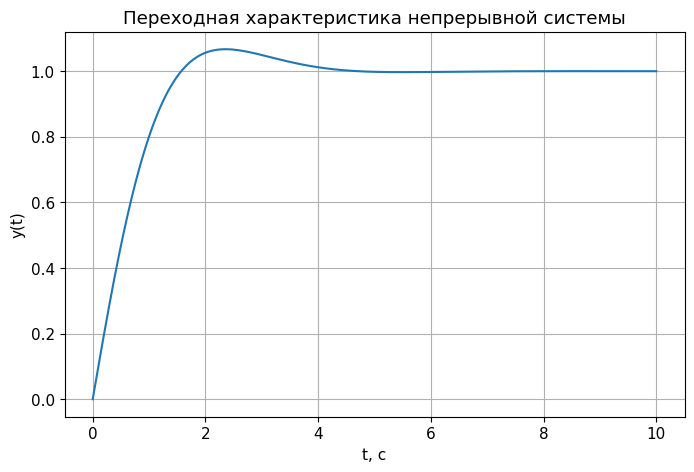

In [ ]:
t = np.linspace(0, 10, 1000)

t_step, y_step = ct.step_response(W, T=t)

plt.figure()
plt.plot(t_step, y_step)
plt.xlabel("t, c")
plt.ylabel("y(t)")
plt.title("Переходная характеристика непрерывной системы")
plt.grid(True)
plt.show()

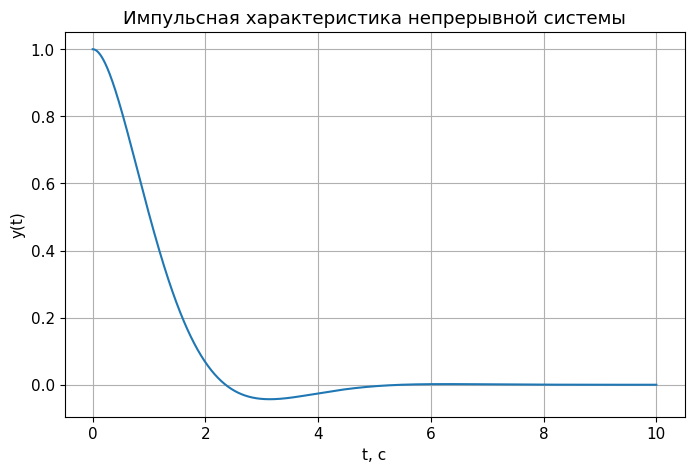

In [ ]:
t_impulse, y_impulse = ct.impulse_response(W, T=t)

plt.figure()
plt.plot(t_impulse, y_impulse)
plt.xlabel("t, c")
plt.ylabel("y(t)")
plt.title("Импульсная характеристика непрерывной системы")
plt.grid(True)
plt.show()

In [ ]:
info = ct.step_info(W)

print("Показатели переходного процесса:")

for key, value in info.items():
    print(f"{key}: {value}")

Показатели переходного процесса:
RiseTime: 1.116404893572871
SettlingTime: 3.7678665158084397
SettlingMin: 0.9118062628228432
SettlingMax: 1.0670024129951534
Overshoot: 6.7002412995153415
Undershoot: 0.0
Peak: 1.0670024129951534
PeakTime: 2.3723603988423507
SteadyStateValue: 1.0


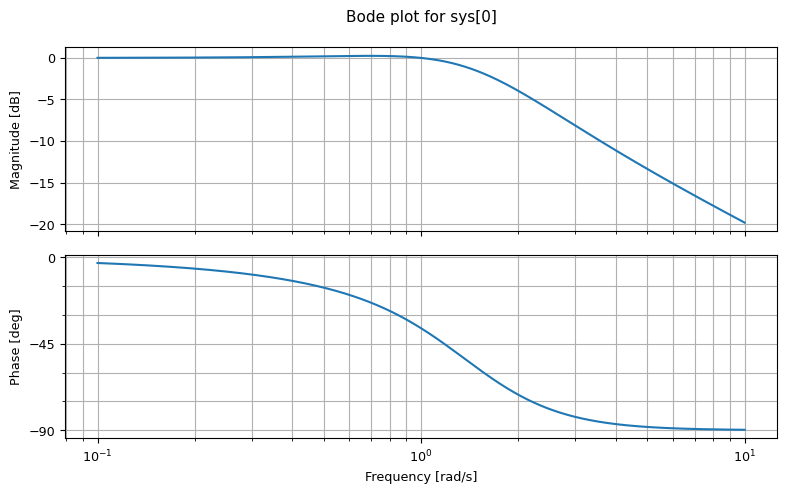

In [ ]:
plt.figure()
ct.bode_plot(W, dB=True, deg=True, grid=True)
plt.show()

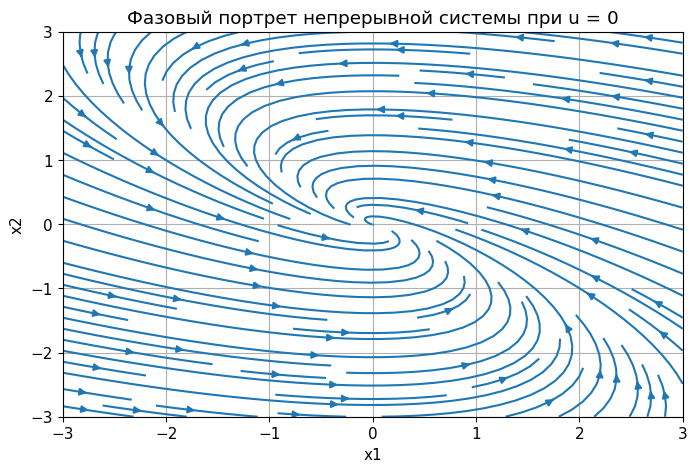

In [ ]:
x1 = np.linspace(-3, 3, 20)
x2 = np.linspace(-3, 3, 20)

X1, X2 = np.meshgrid(x1, x2)

U = A[0, 0] * X1 + A[0, 1] * X2
V = A[1, 0] * X1 + A[1, 1] * X2

plt.figure()
plt.streamplot(X1, X2, U, V, density=1.2)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Фазовый портрет непрерывной системы при u = 0")
plt.grid(True)
plt.show()

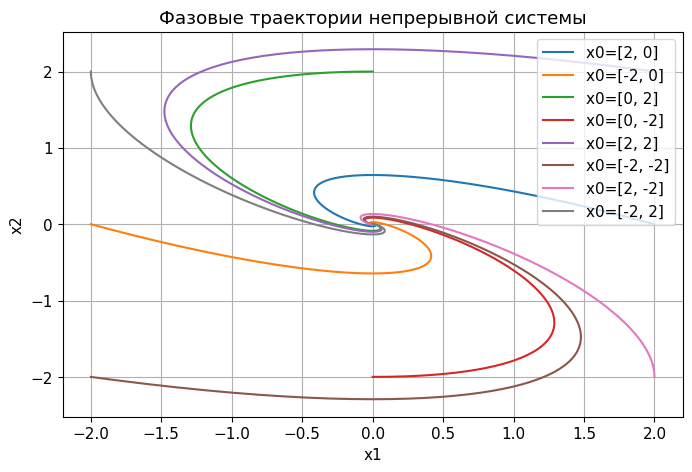

In [ ]:
initial_conditions = [
    [2, 0],
    [-2, 0],
    [0, 2],
    [0, -2],
    [2, 2],
    [-2, -2],
    [2, -2],
    [-2, 2]
]

t_sim = np.linspace(0, 10, 1000)

plt.figure()

for x0 in initial_conditions:
    t_out, y_out, x_out = ct.initial_response(W_ss, T=t_sim, X0=x0, return_x=True)
    plt.plot(x_out[0], x_out[1], label=f"x0={x0}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Фазовые траектории непрерывной системы")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
T = 0.1

Wd = ct.sample_system(W, T, method="zoh")

print("Шаг дискретизации T =", T, "c")
print("\nДискретная передаточная функция W(z):")
print(Wd)

Шаг дискретизации T = 0.1 c

Дискретная передаточная функция W(z):
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.09968 z - 0.08159
  ----------------------
  z^2 - 1.801 z + 0.8187


In [ ]:
discrete_poles = ct.poles(Wd)
discrete_zeros = ct.zeros(Wd)

print("Нули дискретной системы:")
print(discrete_zeros)

print("\nПолюса дискретной системы:")
print(discrete_poles)

is_stable_discrete = np.all(np.abs(discrete_poles) < 1)

print("\nУстойчива ли дискретная система?")
print(is_stable_discrete)

print("\nМодули полюсов:")
print(np.abs(discrete_poles))

Нули дискретной системы:
[0.81845698+0.j]

Полюса дискретной системы:
[0.900317+0.09033301j 0.900317-0.09033301j]

Устойчива ли дискретная система?
True

Модули полюсов:
[0.90483742 0.90483742]


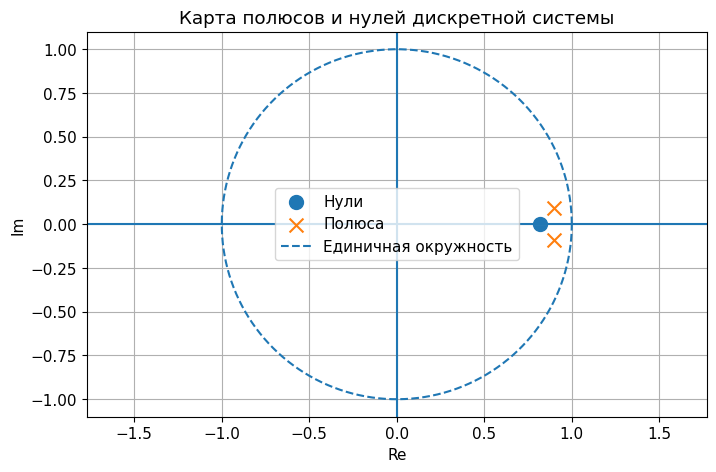

In [ ]:
plt.figure()

plt.scatter(np.real(discrete_zeros), np.imag(discrete_zeros), marker="o", s=100, label="Нули")
plt.scatter(np.real(discrete_poles), np.imag(discrete_poles), marker="x", s=100, label="Полюса")

theta = np.linspace(0, 2 * np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linestyle="--", label="Единичная окружность")

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Карта полюсов и нулей дискретной системы")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

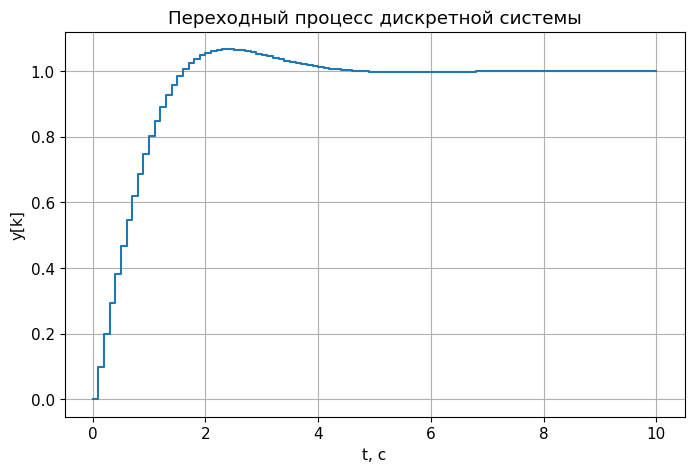

In [ ]:
t_discrete = np.arange(0, 10 + T, T)

t_step_d, y_step_d = ct.step_response(Wd, T=t_discrete)

plt.figure()
plt.step(t_step_d, y_step_d, where="post")
plt.xlabel("t, c")
plt.ylabel("y[k]")
plt.title("Переходный процесс дискретной системы")
plt.grid(True)
plt.show()

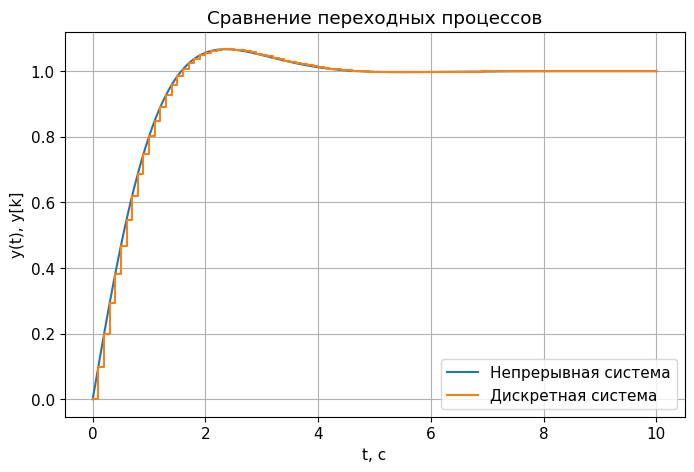

In [ ]:
plt.figure()

plt.plot(t_step, y_step, label="Непрерывная система")
plt.step(t_step_d, y_step_d, where="post", label="Дискретная система")

plt.xlabel("t, c")
plt.ylabel("y(t), y[k]")
plt.title("Сравнение переходных процессов")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
summary_text = f"""
Вывод по лабораторной работе

В работе была исследована динамическая система по варианту 1.

Исходное дифференциальное уравнение:
y''(t) + 2y'(t) + 2y(t) = u'(t) + 2u(t)

Передаточная функция системы:
W(s) = (s + 2) / (s^2 + 2s + 2)

Полюса непрерывной системы:
{poles}

Нули непрерывной системы:
{zeros}

Непрерывная система устойчива:
{is_stable}

Ранг матрицы управляемости:
{rank_ctrb}

Ранг матрицы наблюдаемости:
{rank_obsv}

Система полностью управляема:
{rank_ctrb == n}

Система полностью наблюдаема:
{rank_obsv == n}

Шаг дискретизации:
T = {T} c

Полюса дискретной системы:
{discrete_poles}

Модули полюсов дискретной системы:
{np.abs(discrete_poles)}

Дискретная система устойчива:
{is_stable_discrete}

Итог:
Непрерывная система является устойчивой, управляемой и наблюдаемой.
После перехода к дискретному описанию при шаге T = 0.1 c устойчивость сохраняется,
так как полюса дискретной системы находятся внутри единичной окружности.
"""

print(summary_text)


Вывод по лабораторной работе

В работе была исследована динамическая система по варианту 1.

Исходное дифференциальное уравнение:
y''(t) + 2y'(t) + 2y(t) = u'(t) + 2u(t)

Передаточная функция системы:
W(s) = (s + 2) / (s^2 + 2s + 2)

Полюса непрерывной системы:
[-1.+1.j -1.-1.j]

Нули непрерывной системы:
[-2.+0.j]

Непрерывная система устойчива:
True

Ранг матрицы управляемости:
2

Ранг матрицы наблюдаемости:
2

Система полностью управляема:
True

Система полностью наблюдаема:
True

Шаг дискретизации:
T = 0.1 c

Полюса дискретной системы:
[0.900317+0.09033301j 0.900317-0.09033301j]

Модули полюсов дискретной системы:
[0.90483742 0.90483742]

Дискретная система устойчива:
True

Итог:
Непрерывная система является устойчивой, управляемой и наблюдаемой.
После перехода к дискретному описанию при шаге T = 0.1 c устойчивость сохраняется,
так как полюса дискретной системы находятся внутри единичной окружности.

